**Lab 10**

Develop a program to implement k-means clustering using Wisconsin Breast Cancer data set and visualize the clustering result.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

print(f"Confusion Matrix:\n{confusion_matrix(y, y_kmeans)}\n")
print(f"Classification Report:\n{classification_report(y, y_kmeans)}")

Confusion Matrix:
[[175  37]
 [ 13 344]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       212
           1       0.90      0.96      0.93       357

    accuracy                           0.91       569
   macro avg       0.92      0.89      0.90       569
weighted avg       0.91      0.91      0.91       569



In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df['Cluster'] = y_kmeans
df['True Label'] = y

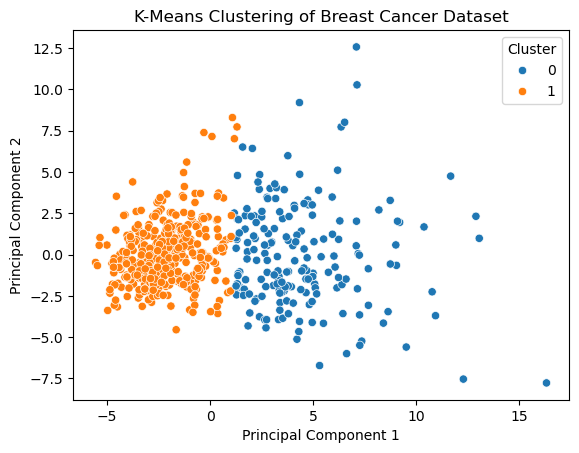

In [4]:
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="Cluster"
)
plt.title("K-Means Clustering of Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

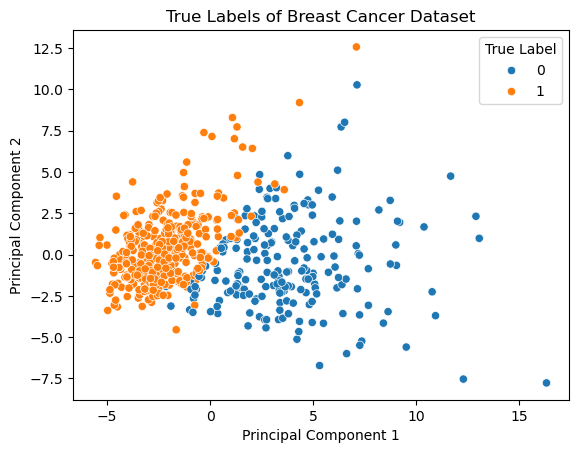

In [5]:
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="True Label"
)
plt.title("True Labels of Breast Cancer Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="True Label")
plt.show()

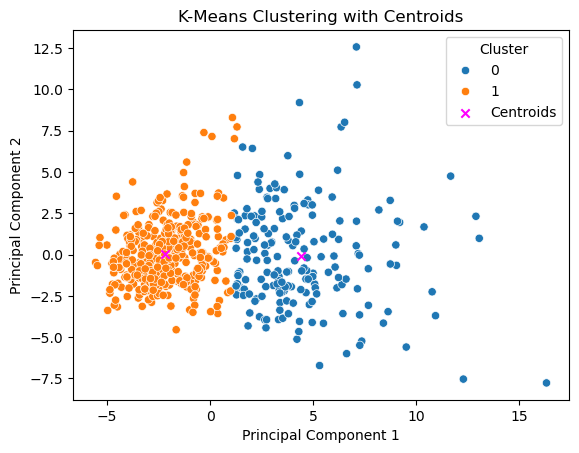

In [15]:
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="Cluster"
)
centers = pca.transform(kmeans.cluster_centers_)

plt.scatter(centers[:, 0], centers[:, 1], c="magenta", marker="x", label="Centroids")
plt.title("K-Means Clustering with Centroids")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()